In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import datasets, layers, models

from sklearn.metrics import confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1156s 7us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [5]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


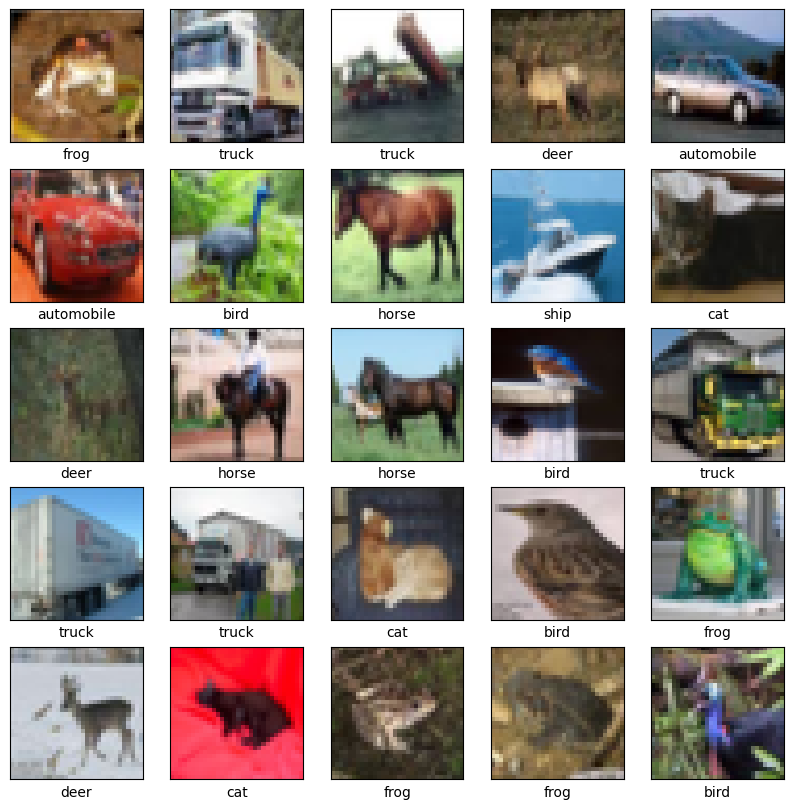

In [6]:
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])

plt.show()


In [7]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Training data range:", x_train.min(), "to", x_train.max())
print("Testing data range:", x_test.min(), "to", x_test.max())

Training data range: 0.0 to 1.0
Testing data range: 0.0 to 1.0


In [8]:
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train_new = x_train[:-5000]
y_train_new = y_train[:-5000]

print("Training set:", x_train_new.shape)
print("Validation set:", x_val.shape)
print("Testing set:", x_test.shape)

Training set: (45000, 32, 32, 3)
Validation set: (5000, 32, 32, 3)
Testing set: (10000, 32, 32, 3)


In [9]:
model = models.Sequential([
    
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    
    layers.Flatten(),
    
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

C:\Users\Karin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [12]:
history = model.fit(
    x_train_new,
    y_train_new,
    epochs=10,
    batch_size=64,
    validation_data=(x_val, y_val)
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.4036 - loss: 1.6251 - val_accuracy: 0.5272 - val_loss: 1.3408
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5478 - loss: 1.2638 - val_accuracy: 0.5774 - val_loss: 1.1804
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6093 - loss: 1.1032 - val_accuracy: 0.6342 - val_loss: 1.0478
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6412 - loss: 1.0124 - val_accuracy: 0.6504 - val_loss: 1.0153
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6734 - loss: 0.9315 - val_accuracy: 0.6718 - val_loss: 0.9466
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6907 - loss: 0.8780 - val_accuracy: 0.6782 - val_loss: 0.9373
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7090 - loss: 0.8322 - val_accuracy: 0.6978 - val_loss: 0.8696
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7242 - loss: 0.7867 - val_acc

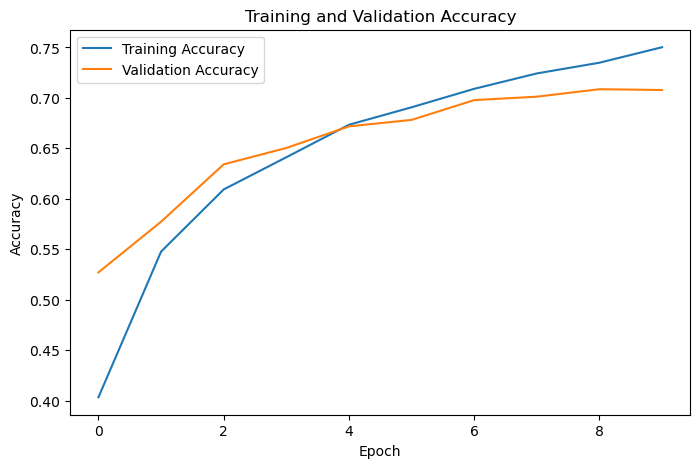

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

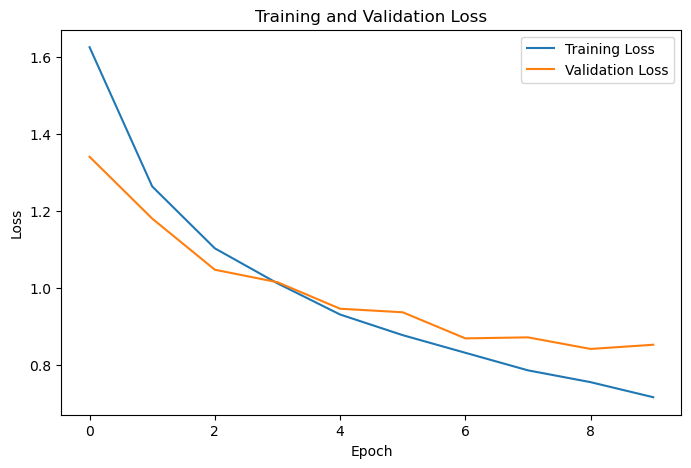

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [15]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6919 - loss: 0.8911
Test Loss: 0.8911358118057251
Test Accuracy: 0.6919000148773193


In [16]:
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 69.19%


In [17]:
y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)

print("Predictions generated successfully!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predictions generated successfully!


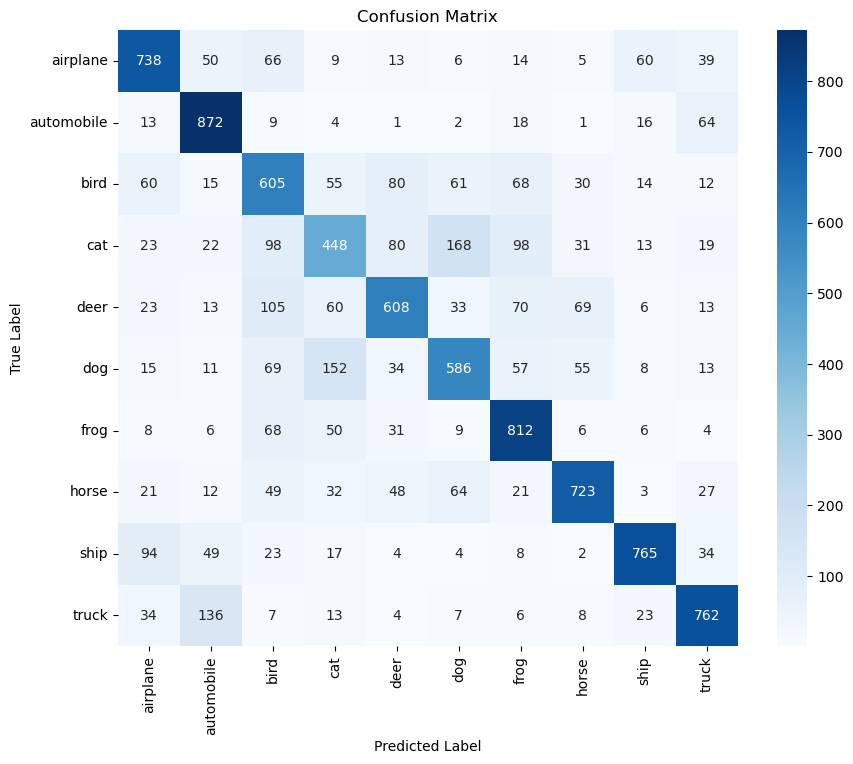

In [18]:
cm = confusion_matrix(
    y_test.flatten(),
    y_pred_classes
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [19]:
print(
    classification_report(
        y_test.flatten(),
        y_pred_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.72      0.74      0.73      1000
  automobile       0.74      0.87      0.80      1000
        bird       0.55      0.60      0.58      1000
         cat       0.53      0.45      0.49      1000
        deer       0.67      0.61      0.64      1000
         dog       0.62      0.59      0.60      1000
        frog       0.69      0.81      0.75      1000
       horse       0.78      0.72      0.75      1000
        ship       0.84      0.77      0.80      1000
       truck       0.77      0.76      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000



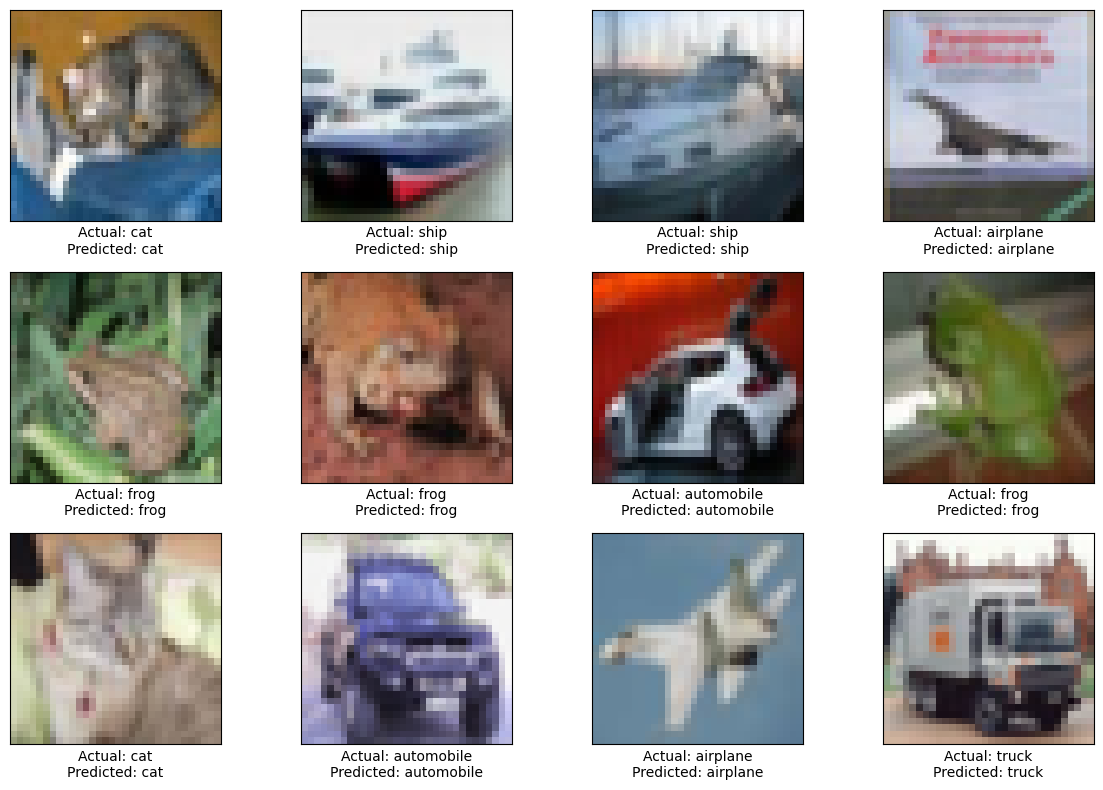

In [20]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(x_test[i])

    actual = class_names[y_test[i][0]]
    predicted = class_names[y_pred_classes[i]]

    plt.xlabel(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

plt.tight_layout()
plt.show()


In [21]:
model.save("cnn_cifar10_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [22]:
loaded_model = tf.keras.models.load_model(
    "cnn_cifar10_model.keras"
)

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [23]:
loaded_loss, loaded_accuracy = loaded_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Loaded Model Accuracy: {loaded_accuracy * 100:.2f}%")

Loaded Model Accuracy: 69.19%


In [24]:
print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (50000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)
